In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/test.csv")

In [3]:
df.head(2)

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_food,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing
0,tour_1,AUSTRALIA,45-64,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,Yes,Yes,10,3,Cash,Yes,Wildlife
1,tour_100,SOUTH AFRICA,25-44,Friends/Relatives,0.0,4.0,Business,Wildlife tourism,Tanzania Mission Abroad,Package Tour,...,No,No,No,No,No,13,0,Cash,No,"Wonderful Country, Landscape, Nature"


In [4]:
df.shape

(1601, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1601 entries, 0 to 1600
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     1601 non-null   object 
 1   country                1601 non-null   object 
 2   age_group              1601 non-null   object 
 3   travel_with            1274 non-null   object 
 4   total_female           1600 non-null   float64
 5   total_male             1599 non-null   float64
 6   purpose                1601 non-null   object 
 7   main_activity          1601 non-null   object 
 8   info_source            1601 non-null   object 
 9   tour_arrangement       1601 non-null   object 
 10  package_transport_int  1601 non-null   object 
 11  package_accomodation   1601 non-null   object 
 12  package_food           1601 non-null   object 
 13  package_transport_tz   1601 non-null   object 
 14  package_sightseeing    1601 non-null   object 
 15  pack

In [6]:
# check how many duplicated rows exist in the data frame
df.duplicated().value_counts()

False    1601
Name: count, dtype: int64

In [7]:
df.describe().T.style \
    .format('{:.2f}')

,count,mean,std,min,25%,50%,75%,max
total_female,1600.00,0.93,1.17,0.00,0.00,1.00,1.00,20.00
total_male,1599.00,1.06,1.31,0.00,1.00,1.00,1.00,40.00
night_mainland,1601.00,8.74,19.79,0.00,2.00,5.00,10.00,664.00
night_zanzibar,1601.00,2.50,6.27,0.00,0.00,0.00,4.00,174.00


In [8]:
df['total_nights']=df['night_mainland']+df['night_zanzibar']

In [9]:
df.isna().sum()

ID                         0
country                    0
age_group                  0
travel_with              327
total_female               1
total_male                 2
purpose                    0
main_activity              0
info_source                0
tour_arrangement           0
package_transport_int      0
package_accomodation       0
package_food               0
package_transport_tz       0
package_sightseeing        0
package_guided_tour        0
package_insurance          0
night_mainland             0
night_zanzibar             0
payment_mode               0
first_trip_tz              0
most_impressing          111
total_nights               0
dtype: int64

<Axes: >

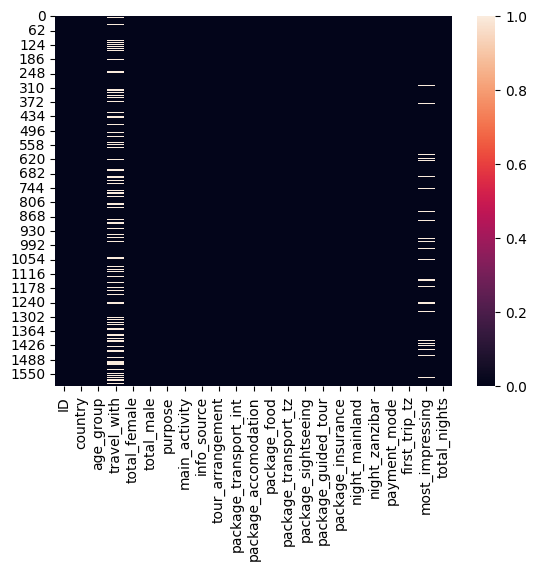

In [10]:
sns.heatmap(df.isna())

In [11]:
#This is to look at what all unique values have
list_col=['ID','country', 'age_group', 'travel_with', 'purpose', 'main_activity', 'info_source',
       'tour_arrangement', 'package_transport_int', 'package_accomodation',
       'package_food', 'package_transport_tz', 'package_sightseeing',
       'package_guided_tour', 'package_insurance', 'payment_mode', 'first_trip_tz', 'most_impressing',]

for col in list_col: 
    print('{} :{} ' . format(col, df[col].nunique()))

ID :1601 
country :87 
age_group :4 
travel_with :5 
purpose :7 
main_activity :9 
info_source :8 
tour_arrangement :2 
package_transport_int :2 
package_accomodation :2 
package_food :2 
package_transport_tz :2 
package_sightseeing :2 
package_guided_tour :2 
package_insurance :2 
payment_mode :4 
first_trip_tz :2 
most_impressing :7 


In [12]:
df[df['total_male'].isna()]

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_nights
54,tour_1189,GERMANY,45-64,Friends/Relatives,4.0,NaN,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,Yes,23,0,Cash,No,Wildlife,23
514,tour_2779,NETHERLANDS,45-64,Friends/Relatives,11.0,NaN,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,No,No,Yes,No,5,0,Cash,Yes,Wildlife,5


In [13]:
most_frequent = df['travel_with'].mode()[0]
df['travel_with'].fillna(most_frequent, inplace=True)

df.most_impressing.fillna('No comments',inplace=True)

df['total_female'] = df['total_female'].fillna(df['total_male'].apply(lambda x: 1 if x == 0 else 0))

df['total_male'] = df['total_male'].fillna(df['total_female'].apply(lambda x: 1 if x == 0 else 0))

In [14]:
df[df['ID']=='tour_2761']



,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_nights
511,tour_2761,FRANCE,25-44,Friends/Relatives,0.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,No,No,Yes,No,9,5,Cash,Yes,No comments,14


In [15]:
df.isna().sum()

ID                       0
country                  0
age_group                0
travel_with              0
total_female             0
total_male               0
purpose                  0
main_activity            0
info_source              0
tour_arrangement         0
package_transport_int    0
package_accomodation     0
package_food             0
package_transport_tz     0
package_sightseeing      0
package_guided_tour      0
package_insurance        0
night_mainland           0
night_zanzibar           0
payment_mode             0
first_trip_tz            0
most_impressing          0
total_nights             0
dtype: int64

In [16]:
df['total_num_fm']=df['total_female']+df['total_male']

In [17]:
desired_order = ['ID', 'country', 'age_group', 'travel_with', 'total_female',
       'total_male', 'total_num_fm', 'purpose', 'main_activity', 'info_source',
       'tour_arrangement', 'package_transport_int', 'package_accomodation',
       'package_food', 'package_transport_tz', 'package_sightseeing',
       'package_guided_tour', 'package_insurance', 'night_mainland',
       'night_zanzibar', 'total_nights', 'payment_mode', 'first_trip_tz', 'most_impressing']

df = df[desired_order]

In [18]:
df.head(2)

,ID,country,age_group,travel_with,total_female,total_male,total_num_fm,purpose,main_activity,info_source,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,total_nights,payment_mode,first_trip_tz,most_impressing
0,tour_1,AUSTRALIA,45-64,Spouse,1.0,1.0,2.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",...,Yes,Yes,Yes,Yes,10,3,13,Cash,Yes,Wildlife
1,tour_100,SOUTH AFRICA,25-44,Friends/Relatives,0.0,4.0,4.0,Business,Wildlife tourism,Tanzania Mission Abroad,...,No,No,No,No,13,0,13,Cash,No,"Wonderful Country, Landscape, Nature"


In [19]:
print(df['age_group'].unique())

['45-64' '25-44' '24-Jan' '65+']


In [20]:
df['age_group'] = df['age_group'].replace('24-Jan', '1-24')

In [21]:
print(df['age_group'].unique())

['45-64' '25-44' '1-24' '65+']


In [22]:
df.to_csv("data/NaN_clean_test.csv", index=False)